#### Étape 1 : Création de l'Environnement et Importations
Cette étape permet de charger toutes les bibliothèques scientifiques nécessaires.

In [1]:
# Importations des librairies fondamentales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importations pour le Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Génération d'un jeu de données de synthèse réaliste pour ce TP
np.random.seed(42)
n_samples = 500

df = pd.DataFrame({
    'Age': np.random.normal(45, 15, n_samples),
    'Revenu': np.random.normal(3000, 1000, n_samples),
    'Score_Medical': np.random.uniform(0, 100, n_samples),
    'Categorie': np.random.choice(['Type_A', 'Type_B', 'Type_C'], n_samples),
    'Cible': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]) # Variable à prédire (0 ou 1)
})

# Injection volontaire de valeurs manquantes pour l'exercice (NaN)
df.loc[df.sample(frac=0.1).index, 'Age'] = np.nan
df.loc[df.sample(frac=0.05).index, 'Categorie'] = np.nan

print("Aperçu des données :")
print(df.head())

Aperçu des données :
         Age       Revenu  Score_Medical Categorie  Cible
0  52.450712  3926.177548      16.748258       NaN      0
1        NaN  4909.416640      10.456784    Type_A      1
2  54.715328  1601.432426      63.643025    Type_A      1
3  67.845448  3562.969237      70.647573    Type_C      1
4  41.487699  2349.357431       3.158614    Type_C      1


#### Étape 2 : Analyse Exploratoire et Visualisation des Données (EDA).
Avant de modéliser, il est impératif de comprendre les données et d'identifier les valeurs aberrantes ou manquantes.

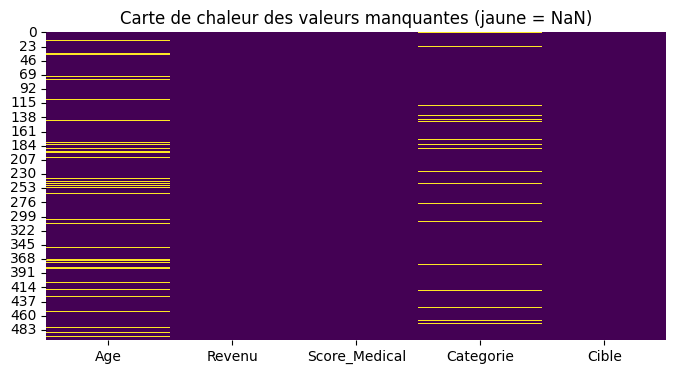

C:\Users\OCELOU\AppData\Local\Temp\ipykernel_8688\3636988095.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cible', palette='pastel')


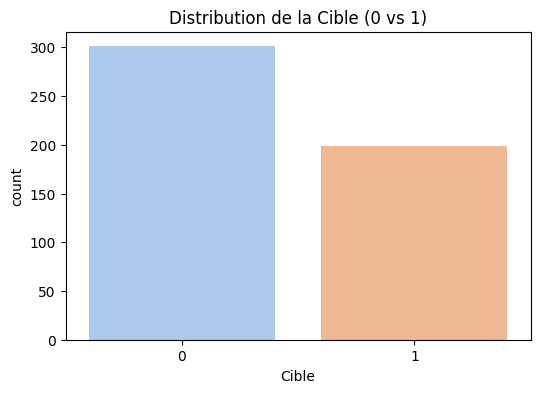

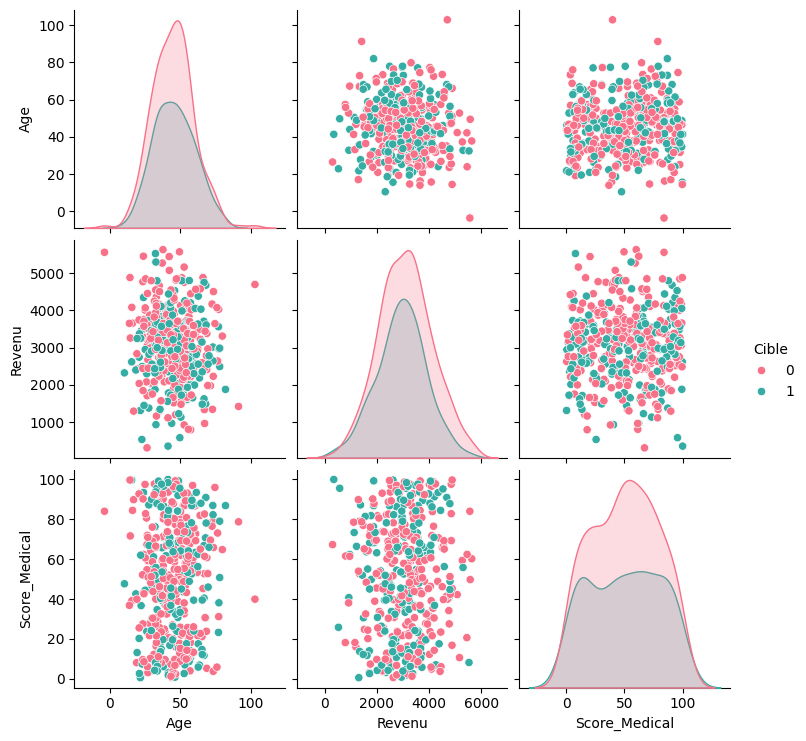

In [2]:
# 2.1 - Gestion visuelle des valeurs manquantes
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Carte de chaleur des valeurs manquantes (jaune = NaN)")
plt.show()

# 2.2 - Distribution de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Cible', palette='pastel')
plt.title("Distribution de la Cible (0 vs 1)")
plt.show()

# 2.3 - Visualisation des relations (Pairplot)
# On ignore les NaN temporairement pour la visualisation
sns.pairplot(df.dropna(), hue='Cible', vars=['Age', 'Revenu', 'Score_Medical'], palette='husl')
plt.show()

#### Étape 3 : Scission des Données (Train / Test Split)
On sépare toujours les données avant d'appliquer les transformations pour éviter le Data Leakage (fuite d'informations du jeu de test vers le jeu d'entraînement).

In [3]:
# Séparation des caractéristiques (X) et de la cible (y)
X = df.drop('Cible', axis=1)
y = df['Cible']

# Division en jeu d'entraînement (80%) et jeu de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")

Dimensions de X_train : (400, 4)
Dimensions de X_test : (100, 4)


#### Étape 4 : Création du Pipeline de Prétraitement et du Modèle
C'est le cœur de l'ingénierie moderne en Data Science. Un Pipeline garantit que toutes les étapes (imputation, encodage, standardisation, modélisation) s'enchaînent parfaitement sans fuite de données.

In [4]:
# 4.1 - Définition des colonnes selon leur type
colonnes_numeriques = ['Age', 'Revenu', 'Score_Medical']
colonnes_categorielles = ['Categorie']

# 4.2 - Pipeline pour les variables numériques (Imputation par médiane + Standardisation)
pipeline_num = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4.3 - Pipeline pour les variables catégorielles (Imputation par le plus fréquent + Encodage)
pipeline_cat = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 4.4 - Combinaison des pipelines dans un ColumnTransformer
preprocesseur = ColumnTransformer(transformers=[
    ('num', pipeline_num, colonnes_numeriques),
    ('cat', pipeline_cat, colonnes_categorielles)
])

# 4.5 - Création du Pipeline final incluant le modèle (Random Forest)
modele_complet = Pipeline(steps=[
    ('preprocesseur', preprocesseur),
    ('classifieur', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5))
])

# Entraînement du modèle sur le jeu de données d'entraînement complet
modele_complet.fit(X_train, y_train)

,steps,"[('preprocesseur', ...), ('classifieur', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Étape 5 : Prédictions, Métriques et Score
On évalue les performances réelles du modèle sur le jeu de test qu'il n'a jamais vu.

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.58      0.88      0.70        60
           1       0.22      0.05      0.08        40

    accuracy                           0.55       100
   macro avg       0.40      0.47      0.39       100
weighted avg       0.44      0.55      0.45       100



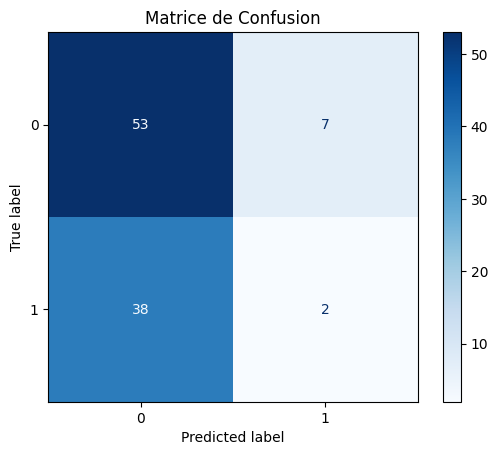

In [5]:
# 5.1 - Génération des prédictions sur le jeu de test
y_pred = modele_complet.predict(X_test)

# 5.2 - Affichage des métriques de classification
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))

# 5.3 - Affichage de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modele_complet.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de Confusion")
plt.show()

#### Étape 6 : Diagnostic avec la Courbe d'Apprentissage (Learning Curve)
Cette étape, permet de vérifier si le modèle est en situation d'Underfitting (sous-apprentissage) ou d'Overfitting (sur-apprentissage).

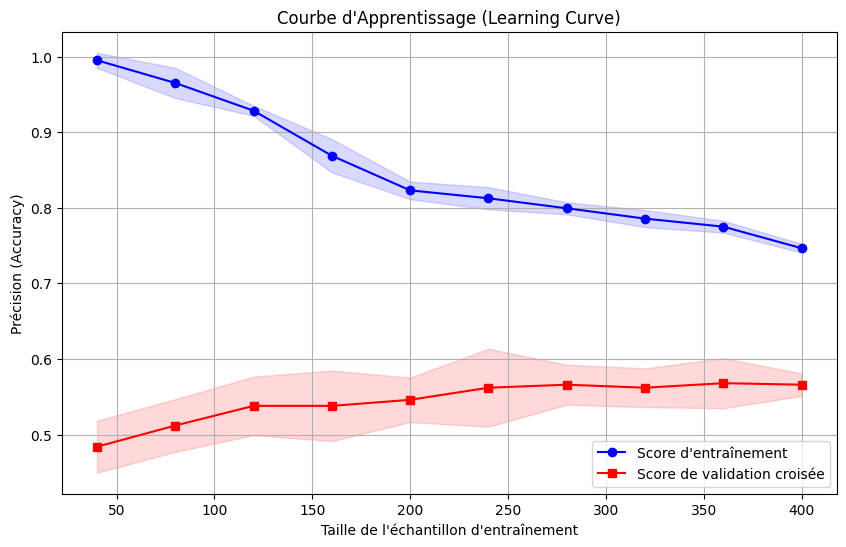

In [6]:
# Génération de la courbe d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    modele_complet, X, y, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calcul des moyennes et écarts-types pour le tracé
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Score d\'entraînement', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.15)

plt.plot(train_sizes, test_mean, label='Score de validation croisée', color='red', marker='s')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.15)

plt.title("Courbe d'Apprentissage (Learning Curve)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Précision (Accuracy)")
plt.legend(loc="lower right")
plt.grid()
plt.show()